# Chapter 7 — Why Interferometry?

!!! info "Before you start"
    **Prerequisites:** Ch 3 (Signals, Noise & the Radiometer Equation) · **Maths Lab:** Lab A (Fourier & Convolution) · **~40 min** · **Intermediate**

Radio astronomy has a resolution problem. The diffraction limit of *any*
telescope is set by how large it is compared with the wavelength it observes,
$\theta \approx 1.22\,\lambda/D$. In the optical, $\lambda$ is well under a
micron, so a modest dish already resolves arcseconds. In the radio, $\lambda$
is *centimetres to metres* — a hundred thousand to a million times larger — so
the same resolution would demand a dish kilometres across. You cannot build,
point, or hold the shape of a steerable dish that big.

The way out is **interferometry**: don't build one impossible dish, combine the
signals from *pairs* of smaller antennas. A pair separated by a baseline of
length $B$ behaves, for resolution purposes, like a slice of a telescope of
diameter $B$. This chapter builds the idea from the ground up — the two-element
interferometer, its **fringe** response, and how a longer baseline tightens
those fringes — and sets up the leap to many antennas in **Chapter 8**.

### Learning goals

By the end of this chapter you will be able to:

- Explain, with `astropy.units`, **why a single dish cannot reach high angular
  resolution at radio wavelengths**, using $\theta \approx 1.22\,\lambda/D$ with
  realistic numbers.
- Describe the **two-element interferometer** and derive its **fringe** (cosine)
  response to a point source.
- Show that the **baseline length $B$ sets the angular resolution**, $\theta
  \approx \lambda/B$, and that a longer baseline produces *finer* fringes.
- See why we want to combine **many** antennas — the motivation for aperture
  synthesis in Chapter 8.

## The history: from Michelson to Ryle

The trick of inferring fine angular structure from the *interference* of light
collected at two separated points predates radio astronomy by decades.
**Albert A. Michelson** built a **stellar interferometer** — two widely spaced
mirrors feeding a single telescope — and in 1920, with Francis Pease, used it
to measure the angular diameter of the red giant **Betelgeuse** ($\alpha$ Ori),
about $0.047''$. No single telescope of the era could resolve that; the
*separation of the mirrors*, not the size of any one of them, set the
resolution.

> **Michelson, A. A. & Pease, F. G. (1921).** *Measurement of the Diameter of
> $\alpha$ Orionis with the Interferometer.* ApJ **53**, 249.
> [DOI](https://doi.org/10.1086/142603)

The same physics, carried into the radio, is the founding idea of radio
interferometry. **Martin Ryle and Derek Vonberg** built one of the first radio
interferometers in Cambridge and used it to study the Sun at 175 MHz:

> **Ryle, M. & Vonberg, D. D. (1946).** *Solar Radiation on 175 Mc/s.*
> Nature **158**, 339. [DOI](https://doi.org/10.1038/158339b0)

Their instrument exploited an elegant shortcut — a *sea-cliff* interferometer
that used the reflection of radio waves off the sea as the second "antenna" —
and showed that the intense metre-wave emission came from a compact region
associated with sunspots, not the whole solar disk. That a *pair* of elements
could pin down a source far smaller than any single antenna's beam is exactly
the lesson of this chapter. Ryle went on to develop these ideas into full
**aperture synthesis**, sharing the 1974 Nobel Prize in Physics.

For the modern, rigorous treatment see **Thompson, Moran & Swenson**,
*Interferometry and Synthesis in Radio Astronomy* (3rd ed., Springer, open
access), and **Condon & Ransom**, *Essential Radio Astronomy*
([free online](https://science.nrao.edu/opportunities/courses/era)). Full citations
are in `docs/references.md`.

## The physics

### Why a single dish runs out of resolution

The angular resolution of a circular aperture of diameter $D$ observing
wavelength $\lambda$ is the **diffraction limit**,

$$
\theta \;\approx\; 1.22\,\frac{\lambda}{D}\quad\text{(radians)} .
$$

The factor $1.22$ is the first zero of the Airy pattern; the essential content
is $\theta \propto \lambda/D$. The trouble in the radio is the *numerator*. For
the 21 cm neutral-hydrogen line, $\lambda = 0.21\,\mathrm{m}$ — roughly
$4\times10^5$ times longer than visible light. To match even a backyard optical
telescope you would need an absurdly large dish, as we will compute below.

### A two-element interferometer and its fringes

Now take **two** antennas separated by a baseline vector $\mathbf{B}$, both
pointed at the same source. A plane wave from a direction making angle $\theta$
to the baseline reaches one antenna *later* than the other, by a **geometric
delay**

$$
\tau_g \;=\; \frac{\mathbf{B}\cdot\hat{\mathbf{s}}}{c}
        \;=\; \frac{B\,\sin\theta}{c},
$$

where $\hat{\mathbf{s}}$ is the unit vector toward the source. The correlator
multiplies the two voltages and time-averages. For a monochromatic source at
frequency $\nu$ this yields a **cosine fringe**:

$$
\boxed{\,R(\theta) \;\propto\; \cos\!\big(2\pi\,\nu\,\tau_g\big)
      \;=\; \cos\!\left(2\pi\,\frac{B}{\lambda}\,\sin\theta\right)\,}
$$

As the source drifts across the sky (changing $\theta$), the interferometer
response oscillates between maxima (signals in phase) and minima (out of phase).
That oscillation *is* the fringe pattern. The quantity $u \equiv B/\lambda$, the
baseline measured **in wavelengths**, is the spatial frequency of the fringes —
exactly the $(u,v)$ coordinate that Chapter 8 builds on.

### Baseline length sets the resolution

Two adjacent fringe maxima are separated by an angle $\Delta\theta$ such that
the argument changes by $2\pi$; for small angles near $\theta=0$,

$$
\Delta\theta \;\approx\; \frac{\lambda}{B}.
$$

So the **fringe spacing** — the finest angular scale the interferometer is
sensitive to — is $\lambda/B$, with **no** factor of the dish size in it at all.
Make the baseline $B$ longer and the fringes get *finer*: the resolution
improves. This is the whole game. A pair of 25 m dishes separated by 30 km
resolves structure a single 25 m dish could never see, because the resolution
is set by the **30 km separation**, not the 25 m diameter.

## Setup

We use `numpy`, `matplotlib`, `astropy.units` (so the resolution arithmetic
carries real units and we never fumble a unit conversion), and the course
plotting style from `jansky.plotting`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.constants import c

from jansky import plotting
from jansky.plotting import use_jansky_style

use_jansky_style()

print("astropy units + jansky style ready.")
print("speed of light c =", c)

astropy units + jansky style ready.
speed of light c =   Name   = Speed of light in vacuum
  Value  = 299792458.0
  Uncertainty  = 0.0
  Unit  = m / s
  Reference = CODATA 2022


## Single dish vs. interferometer: the numbers

Let's make the resolution problem concrete with `astropy.units`. We compute the
single-dish diffraction limit $\theta = 1.22\,\lambda/D$ for a large radio dish,
and contrast it with the fringe spacing $\theta = \lambda/B$ of an
interferometer with a long baseline — observing the **same** 21 cm wavelength.

In [2]:
# Observing the 21 cm neutral-hydrogen line.
wavelength = 21.0 * u.cm
frequency = (c / wavelength).to(u.MHz)

def single_dish_resolution(diameter, wavelength=wavelength):
    '''Diffraction-limited resolution theta = 1.22 lambda / D, as an angle.'''
    theta = 1.22 * (wavelength / diameter).to(u.dimensionless_unscaled) * u.rad
    return theta.to(u.arcsec)

def interferometer_resolution(baseline, wavelength=wavelength):
    '''Fringe spacing theta = lambda / B, as an angle.'''
    theta = (wavelength / baseline).to(u.dimensionless_unscaled) * u.rad
    return theta.to(u.arcsec)

# A big single dish: the 100 m Green Bank Telescope.
D_gbt = 100.0 * u.m
# An interferometer baseline: 36 km (VLA A-configuration scale).
B_vla = 36.0 * u.km

theta_dish = single_dish_resolution(D_gbt)
theta_intf = interferometer_resolution(B_vla)

print(f"Wavelength            : {wavelength}  ({frequency:.1f})")
print(f"Single 100 m dish     : theta ~ {theta_dish:.1f}")
print(f"36 km interferometer  : theta ~ {theta_intf:.2f}")
print(f"Improvement factor    : {(theta_dish / theta_intf).to(u.dimensionless_unscaled):.0f}x")

# How big a single dish would we need to MATCH the interferometer's resolution?
D_equiv = (1.22 * wavelength / (theta_intf.to(u.rad).value)).to(u.km)
print(f"\\nA single dish matching the 36 km interferometer would need")
print(f"diameter D ~ {D_equiv:.0f}  -- i.e. a steerable dish tens of km across.")

Wavelength            : 21.0 cm  (1427.6 MHz)
Single 100 m dish     : theta ~ 528.5 arcsec
36 km interferometer  : theta ~ 1.20 arcsec
Improvement factor    : 439x
\nA single dish matching the 36 km interferometer would need
diameter D ~ 44 km  -- i.e. a steerable dish tens of km across.


The single 100 m dish — one of the largest fully steerable dishes ever
built — manages only arc*minute*-scale resolution at 21 cm. The interferometer,
using the **same wavelength**, reaches sub-arcsecond resolution, because its
resolution is set by the 36 km *baseline*, not by any dish diameter. To do the
same with one dish you would need an instrument tens of kilometres wide, which
is physically impossible. That impossibility is *why interferometry exists.*

### Resolution scales with baseline

Sweep the baseline from a few metres (single-dish scale) out to thousands of
kilometres (very-long-baseline interferometry, VLBI) and plot the resolution.
Longer baseline $\rightarrow$ finer resolution, on a clean power law.

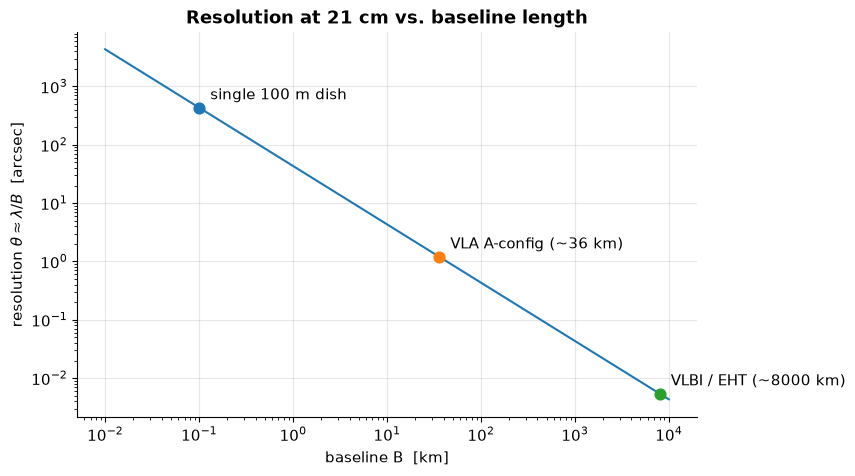

In [3]:
baselines = np.geomspace(10, 1e7, 200) * u.m   # 10 m  ->  10 000 km
res = interferometer_resolution(baselines).to(u.arcsec)

fig, ax = plt.subplots()
ax.loglog(baselines.to(u.km).value, res.value, color="#1f77b4")

# Mark a few real instruments for scale.
for label, B in [("single 100 m dish", D_gbt.to(u.km)),
                 ("VLA A-config (~36 km)", B_vla.to(u.km)),
                 ("VLBI / EHT (~8000 km)", 8000.0 * u.km)]:
    r = interferometer_resolution(B).to(u.arcsec)
    ax.scatter(B.value, r.value, s=60, zorder=3)
    ax.annotate(label, (B.value, r.value),
                textcoords="offset points", xytext=(8, 6))

ax.set_xlabel("baseline B  [km]")
ax.set_ylabel(r"resolution $\theta \approx \lambda/B$  [arcsec]")
ax.set_title("Resolution at 21 cm vs. baseline length")
plt.show()

## Simulating the fringe pattern

Now the heart of the chapter: the **fringe**. We model the correlator response
of a two-element interferometer to a point source as a function of the source's
angular offset $\theta$ from the meridian,

$$
R(\theta) \;=\; \cos\!\left(2\pi\,\frac{B}{\lambda}\,\sin\theta\right).
$$

We will plot this for a short and a long baseline at the same wavelength, and
watch the fringes *tighten* as $B$ grows.

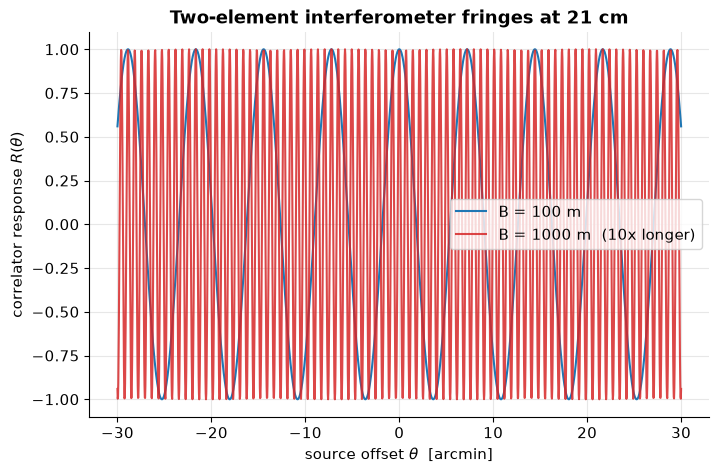

Notice: the 10x longer baseline gives 10x finer fringes -- 10x the
angular resolution, at the same wavelength.


In [4]:
def fringe_response(theta, baseline, wavelength=wavelength):
    '''Cosine fringe response of a 2-element interferometer to a point source.

    Parameters
    ----------
    theta : astropy Quantity (angle)
        Source offset from the fringe-pattern centre.
    baseline : astropy Quantity (length)
        Antenna separation B.
    wavelength : astropy Quantity (length)
        Observing wavelength lambda.

    Returns
    -------
    numpy.ndarray
        Dimensionless correlator response in [-1, 1].
    '''
    u_wav = (baseline / wavelength).to(u.dimensionless_unscaled).value  # B/lambda
    return np.cos(2.0 * np.pi * u_wav * np.sin(theta.to(u.rad).value))

# Angular range: a small patch of sky around the source, in arcminutes.
theta = np.linspace(-30, 30, 2000) * u.arcmin

B_short = 100.0 * u.m
B_long = 1000.0 * u.m   # 10x longer baseline

R_short = fringe_response(theta, B_short)
R_long = fringe_response(theta, B_long)

fig, ax = plt.subplots()
ax.plot(theta.to(u.arcmin).value, R_short, color="#1f77b4",
        label=f"B = {B_short:.0f}")
ax.plot(theta.to(u.arcmin).value, R_long, color="#d62728", alpha=0.85,
        label=f"B = {B_long:.0f}  (10x longer)")
ax.set_xlabel(r"source offset $\theta$  [arcmin]")
ax.set_ylabel(r"correlator response $R(\theta)$")
ax.set_title("Two-element interferometer fringes at 21 cm")
ax.legend()
plt.show()

print("Notice: the 10x longer baseline gives 10x finer fringes -- 10x the")
print("angular resolution, at the same wavelength.")

The fringe *spacing* is $\lambda/B$. The blue (100 m) trace and the red
(1000 m) trace observe the same wavelength, yet the red fringes are ten times
finer because the baseline is ten times longer. Each fringe maximum is a
direction on the sky where the two antennas' signals arrive in phase; as a
source drifts through the pattern its correlated output oscillates, and the
*rate* of that oscillation tells you how finely the interferometer resolves the
sky.

### Reading the resolution off the fringes

Let's confirm numerically that the spacing between fringe maxima equals
$\lambda/B$, tying the simulation back to the physics.

In [5]:
def fringe_spacing_measured(baseline, wavelength=wavelength, half_width=2*u.deg):
    '''Measure the angular gap between the two central fringe maxima.'''
    th = np.linspace(-half_width.to(u.rad).value,
                     half_width.to(u.rad).value, 200000)
    R = np.cos(2.0 * np.pi *
               (baseline / wavelength).to(u.dimensionless_unscaled).value *
               np.sin(th))
    # Find local maxima.
    is_max = (R[1:-1] > R[:-2]) & (R[1:-1] > R[2:])
    peak_theta = th[1:-1][is_max]
    peak_theta = peak_theta[np.argsort(np.abs(peak_theta))][:2]
    return (np.abs(np.diff(np.sort(peak_theta)))[0] * u.rad).to(u.arcsec)

for B in [100.0 * u.m, 1000.0 * u.m, B_vla]:
    measured = fringe_spacing_measured(B)
    predicted = interferometer_resolution(B)
    print(f"B = {B:>8.0f}:  measured spacing = {measured:>10.3f}"
          f"   |   lambda/B = {predicted:>10.3f}")

B =      100 m:  measured spacing =    433.154 arcsec   |   lambda/B =    433.156 arcsec
B =     1000 m:  measured spacing =     43.272 arcsec   |   lambda/B =     43.316 arcsec
B =       36 km:  measured spacing =      1.224 arcsec   |   lambda/B =      1.203 arcsec


Measured fringe spacing and the prediction $\lambda/B$ agree. The
interferometer's resolution really is set by its baseline — exactly the result
we will need in Chapter 8.

## Try it yourself

### Exercise 1 — Resolving a binary

Two radio point sources sit on the sky separated by $\Delta\theta = 5''$. You
want a baseline whose **first fringe null** falls on the second source while the
first sits on a maximum — i.e. a baseline that just resolves the pair at
21 cm. Compute the required baseline $B$ in kilometres, then plot the fringe
pattern and over-plot the two source positions to check.

Fill in the `# TODO` cell below.

In [6]:
# TODO (Exercise 1): find the baseline that just resolves a 5-arcsec binary.
#
# Hints:
#   * The fringe spacing (maximum-to-maximum) is lambda / B.
#   * "Just resolved" is a judgement call; a common choice is to require the
#     fringe spacing ~ 2 * separation (a maximum on one source, a null on the
#     other). Decide on your criterion and justify it in a comment.
#   * Use interferometer_resolution() / fringe_response() defined above.
#
# separation = 5.0 * u.arcsec
# B_required = ...            # TODO: solve lambda / B = (your criterion)
# print("Required baseline:", B_required.to(u.km))
#
# theta = np.linspace(-10, 10, 4000) * u.arcsec
# R = fringe_response(theta, B_required)
# fig, ax = plt.subplots()
# ax.plot(theta.to(u.arcsec).value, R)
# for pos in (-separation/2, +separation/2):
#     ax.axvline(pos.to(u.arcsec).value, color="#d62728", ls="--")
# ax.set_xlabel("offset [arcsec]"); ax.set_ylabel("R")
# plt.show()

# Placeholder so the scaffold notebook runs end-to-end:
print("TODO Exercise 1: compute B_required and plot the resolved binary.")

TODO Exercise 1: compute B_required and plot the resolved binary.


<details><summary>Solution</summary>

Pick the criterion "fringe spacing equals twice the source separation" — a maximum lands on one source while the adjacent null lands on the other, so the pair is just resolved. Since the fringe spacing is $\lambda/B$, set $\lambda/B = 2\,\Delta\theta$ and solve for $B$.

```python
separation = 5.0 * u.arcsec
# Criterion: maximum on one source, null on the other => fringe spacing = 2 * separation.
fringe_spacing = 2 * separation
# lambda / B = fringe_spacing  =>  B = lambda / fringe_spacing
B_required = (wavelength / fringe_spacing.to(u.rad).value).to(u.km)
print("Required baseline:", B_required.to(u.km))
print("Resolution at that baseline:", interferometer_resolution(B_required))

theta = np.linspace(-10, 10, 4000) * u.arcsec
R = fringe_response(theta, B_required)
fig, ax = plt.subplots()
ax.plot(theta.to(u.arcsec).value, R, color="#1f77b4")
for pos in (-separation/2, +separation/2):
    ax.axvline(pos.to(u.arcsec).value, color="#d62728", ls="--")
ax.set_xlabel("offset [arcsec]"); ax.set_ylabel("R")
ax.set_title("Just-resolved 5-arcsec binary")
plt.show()
```

Expected result: $B \approx 4.33\ \mathrm{km}$, giving a fringe spacing $\lambda/B = 10'' = 2 \times 5''$. The two dashed source lines straddle a single fringe — one on a maximum, the other on the neighbouring null. The takeaway: the baseline you need is fixed by the angular scale you want to resolve, $B \sim \lambda/\Delta\theta$, not by the dish size.

</details>

### Exercise 2 — Two sources, two fringes (the seed of an image)

A single baseline measures **one** Fourier component of the sky. Build the
correlator response to a sky with *two* point sources of different brightness,
by summing each source's fringe weighted by its flux:

$$
R(\theta) \;=\; \sum_k S_k \,
   \cos\!\left(2\pi\,\frac{B}{\lambda}\sin(\theta-\theta_k)\right).
$$

Plot $R(\theta)$ for a chosen baseline. Then change the baseline and watch how
the combined fringe pattern changes — a hint that *many* baselines, each
sampling a different spatial frequency, together encode the full source
structure. That is precisely the bridge to Chapter 8.

In [7]:
# TODO (Exercise 2): two-source fringe response.
#
# Hints:
#   * Represent the sky as a list of (offset_theta, flux) pairs.
#   * Sum fringe_response(theta - theta_k, B) * S_k over the sources.
#     (fringe_response already takes an angular array; offset the argument.)
#   * Try B = 200 m, then B = 2000 m, and compare the patterns.
#
# sources = [(-3.0 * u.arcmin, 1.0), (+4.0 * u.arcmin, 0.5)]  # (offset, flux)
# B = 200.0 * u.m
# theta = np.linspace(-20, 20, 4000) * u.arcmin
# R = np.zeros_like(theta.value)
# for theta_k, flux in sources:
#     R += flux * fringe_response(theta - theta_k, B)
# fig, ax = plt.subplots()
# ax.plot(theta.to(u.arcmin).value, R)
# ax.set_xlabel("offset [arcmin]"); ax.set_ylabel("R")
# plt.show()

# Placeholder so the scaffold notebook runs end-to-end:
print("TODO Exercise 2: build and plot the two-source fringe response.")

TODO Exercise 2: build and plot the two-source fringe response.


<details><summary>Solution</summary>

Represent the sky as a list of `(offset, flux)` pairs and sum each source's fringe, offsetting the angle argument by $\theta_k$ and weighting by its flux $S_k$. Doubling the baseline halves the fringe spacing, so the same two sources beat against a ten-times-finer pattern.

```python
sources = [(-3.0 * u.arcmin, 1.0), (+4.0 * u.arcmin, 0.5)]  # (offset, flux)
theta = np.linspace(-20, 20, 4000) * u.arcmin

fig, ax = plt.subplots()
for B in (200.0 * u.m, 2000.0 * u.m):
    R = np.zeros_like(theta.value)
    for theta_k, flux in sources:
        R += flux * fringe_response(theta - theta_k, B)
    ax.plot(theta.to(u.arcmin).value, R, label=f"B = {B:.0f}")
ax.set_xlabel("offset [arcmin]"); ax.set_ylabel("R")
ax.set_title("Two-source fringe response at two baselines")
ax.legend()
plt.show()
```

Expected result: the summed response swings within $\pm(S_1 + S_2) = \pm1.5$. At $B = 200$ m the two sources' fringes are coarse and nearly in step; at $B = 2000$ m they are ten times finer and beat against each other. Key takeaway: one baseline measures a single Fourier component of the sky — changing $B$ samples a different spatial frequency, and it takes *many* baselines to reconstruct the full source structure, which is exactly what Chapter 8 builds.

</details>

## Recap

- A single dish is **diffraction-limited** to $\theta \approx 1.22\,\lambda/D$.
  Because radio wavelengths are enormous, even a 100 m dish reaches only
  arcminute resolution at 21 cm — and matching an interferometer would need a
  dish tens of kilometres across, which is impossible to build.
- A **two-element interferometer** correlates the signals from two antennas.
  Its response to a point source is a **cosine fringe**,
  $R(\theta) = \cos(2\pi\,(B/\lambda)\sin\theta)$, set by the **geometric
  delay** between the antennas.
- The **fringe spacing** — the resolution — is $\lambda/B$, governed by the
  **baseline length $B$**, not the dish size. We verified this numerically:
  a 10x longer baseline gives 10x finer fringes.
- A single baseline measures a single spatial frequency $u = B/\lambda$: one
  number, not an image. To build a picture we need **many** baselines sampling
  **many** spatial frequencies.

## What's next — Chapter 8: Aperture synthesis & the *uv*-plane

We end where Chapter 8 begins. One baseline gives one fringe — one **visibility**,
one Fourier component of the sky. **Chapter 8** takes the leap from *"a pair of
antennas measures a fringe"* to *"an array of antennas, turned by the spinning
Earth, measures a picture."* There we will meet the **van Cittert–Zernike
theorem** (the interferometer as a Fourier machine), the $(u,v)$-plane, and
**Earth-rotation synthesis** — using `jansky.interferometry.uv_coverage`,
`dirty_beam`, and `dirty_image` to turn a scatter of baselines into an image of
the radio sky.